In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"Cleaned_Transformed_Customers.csv")

In [3]:
df.head()

,Unnamed: 0,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,...,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Service Adoption Score,Customer Segment,Revenue Segment,Risk Category
0,0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,...,108.15,Yes,1,86,3239,Competitor made better offer,2,New Customer,Medium,Critical Risk
1,1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,...,151.65,Yes,1,67,2701,Moved,0,New Customer,High,High risk
2,2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,...,820.5,Yes,1,86,5372,Moved,3,New Customer,Premium,Critical Risk
3,3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,...,3046.05,Yes,1,84,5003,Moved,4,Regular Customer,Premium,Critical Risk
4,4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,...,5036.3,Yes,1,89,5340,Competitor had better devices,4,Loyal Customer,Premium,Critical Risk


In [4]:
df.shape

(7043, 38)

Customer Profile Analysis

In [6]:
gender = df['Gender'].value_counts()
print(gender)

Gender
Male      3555
Female    3488
Name: count, dtype: int64


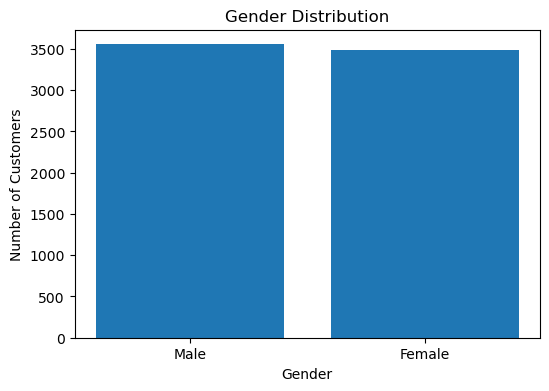

In [9]:
plt.figure(figsize=(6,4))
plt.bar(gender.index,gender.values)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

The customer base is almost equally distributed between male (3555) and female (3488) customers.
This indicates that the telecom company's services appeal equally to both genders.
Gender alone is unlikely to be a major factor influencing customer churn.

In [20]:
Senior = df['Senior Citizen'].value_counts()
print(Senior)

Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64


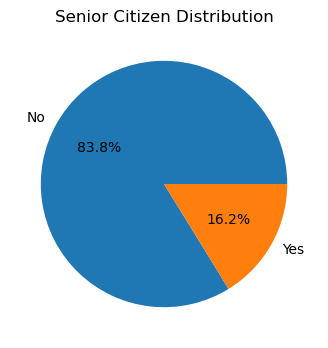

In [21]:
plt.figure(figsize=(6,4))
plt.pie(Senior.values,labels=Senior.index,autopct="%1.1f%%")
plt.title("Senior Citizen Distribution")
plt.show()

Around 84% of customers are non-senior citizens, while only about 16% are senior citizens.
This shows that the company's primary customer base consists of younger and middle-aged individuals.
Further analysis can determine whether senior citizens have different churn behavior.

In [22]:
partner = df['Partner'].value_counts()
print(partner)

Partner
No     3641
Yes    3402
Name: count, dtype: int64


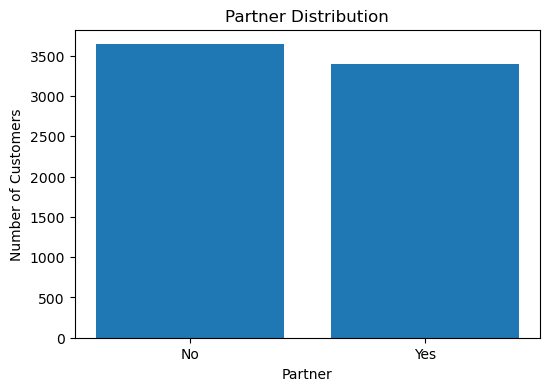

In [15]:
plt.figure(figsize=(6,4))
partner = df["Partner"].value_counts()
plt.bar(partner.index, partner.values)
plt.title("Partner Distribution")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

plt.show()

The number of customers with and without partners is fairly balanced.
Customers without partners slightly outnumber those with partners.
This suggests that partner status alone may not significantly influence customer acquisition, but it can be explored further in churn analysis.

In [23]:
dependents = df['Dependents'].value_counts()
print(dependents)

Dependents
No     5416
Yes    1627
Name: count, dtype: int64


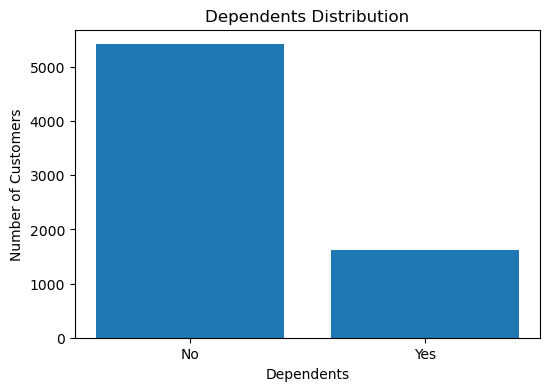

In [17]:
plt.figure(figsize=(6,4))
dependents = df["Dependents"].value_counts()
plt.bar(dependents.index, dependents.values)
plt.title("Dependents Distribution")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

plt.show()

A large majority of customers (5416) do not have dependents.
Customers with dependents make up a much smaller portion of the customer base.
This demographic difference can be analyzed further to understand whether customers with dependents are more loyal.

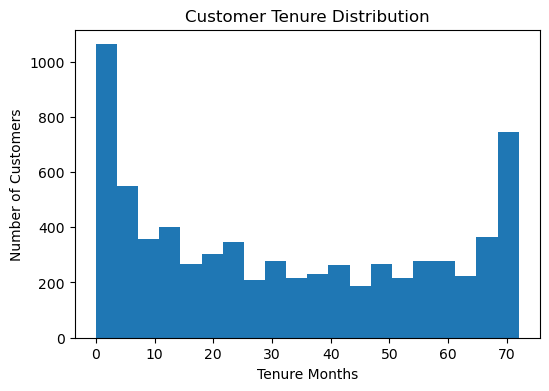

In [19]:
plt.figure(figsize=(6,4))
plt.hist(df["Tenure Months"], bins=20)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure Months")
plt.ylabel("Number of Customers")
plt.show()

A high number of customers have very low tenure (0–5 months).
There is another concentration of customers with high tenure (around 70–72 months).
Fewer customers fall in the middle tenure range.

Customer Profile Summary:

The customer base is almost evenly split between male and female customers.
Most customers are non-senior citizens.
Partner status is nearly balanced across the customer base.
A majority of customers do not have dependents.
Customer tenure shows two major groups: newly joined customers and long-term loyal customers, making tenure an important factor for further churn analysis.

Revenue Analysis

In [24]:
average_revenue = df["Monthly Charges"].mean()

print("Average Monthly Revenue:", round(average_revenue,2))

Average Monthly Revenue: 64.76


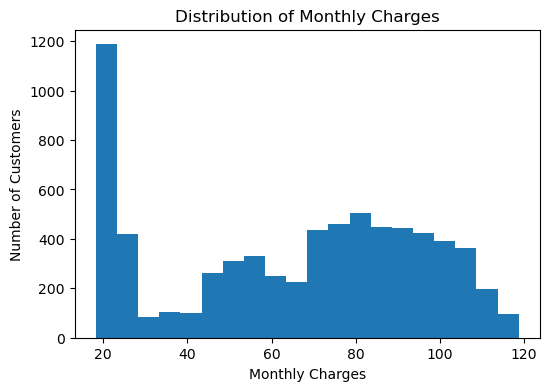

In [25]:
plt.figure(figsize=(6,4))

plt.hist(df["Monthly Charges"], bins=20)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

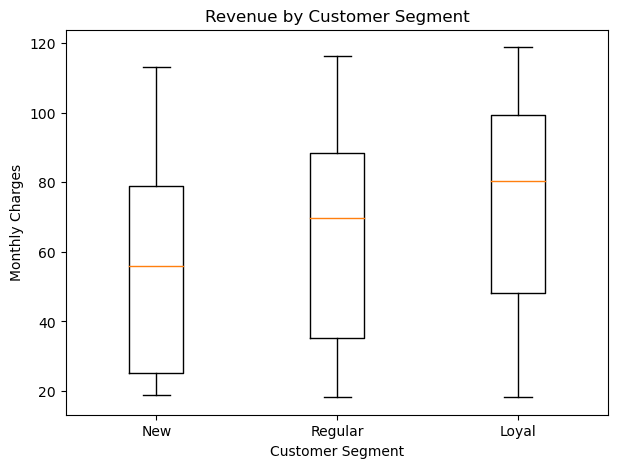

In [26]:
#Revenue by Customer Segment
plt.figure(figsize=(7,5))

plt.boxplot(
    [
        df[df["Customer Segment"]=="New Customer"]["Monthly Charges"],
        df[df["Customer Segment"]=="Regular Customer"]["Monthly Charges"],
        df[df["Customer Segment"]=="Loyal Customer"]["Monthly Charges"]
    ],
    labels=["New","Regular","Loyal"]
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Monthly Charges")

plt.show()

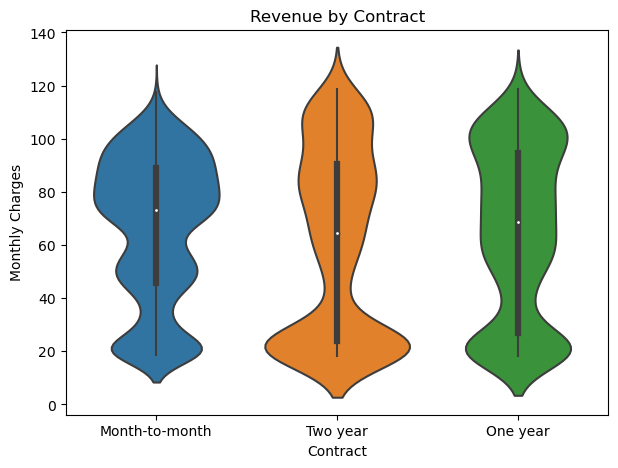

In [27]:
#Revenue by Contract
plt.figure(figsize=(7,5))

sns.violinplot(
    data=df,
    x="Contract",
    y="Monthly Charges"
)

plt.title("Revenue by Contract")
plt.xlabel("Contract")
plt.ylabel("Monthly Charges")

plt.show()

Churn Analysis

In [4]:
#Churn Distribution
churn = pd.crosstab(df["Churn Label"], columns="Count")

print(churn)

col_0        Count
Churn Label       
No            5174
Yes           1869


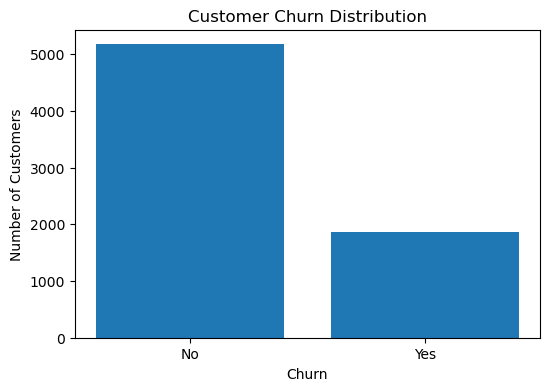

In [9]:
plt.figure(figsize=(6,4))

plt.bar(churn.index, churn["Count"])

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [11]:
#Churn by Contract Type
contract_churn = pd.crosstab(df["Contract"],df["Churn Label"])
print(contract_churn)

Churn Label       No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


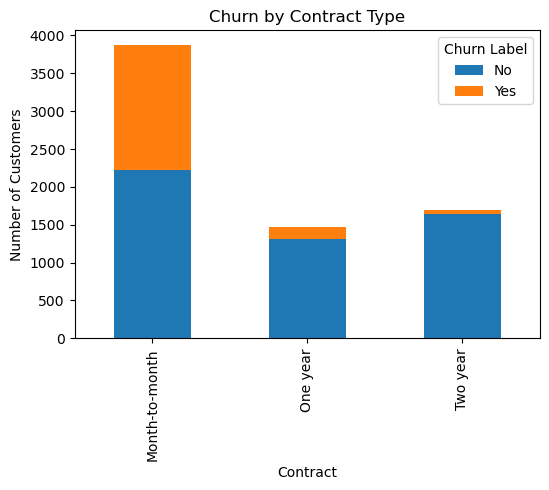

In [13]:
contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")

plt.show()

In [14]:
#Churn by Payment Method
payment_churn = pd.crosstab(df["Payment Method"], df["Churn Label"])

print(payment_churn)

Churn Label                  No   Yes
Payment Method                       
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308


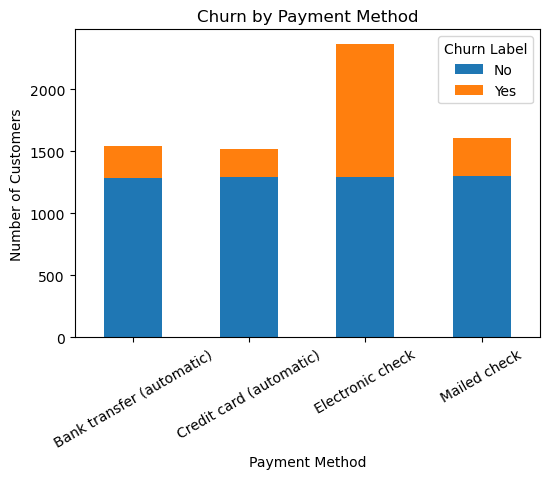

In [16]:
payment_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

In [18]:
#Churn by Internet Service
internet_churn = pd.crosstab(df["Internet Service"], df["Churn Label"])

print(internet_churn)

Churn Label         No   Yes
Internet Service            
DSL               1962   459
Fiber optic       1799  1297
No                1413   113


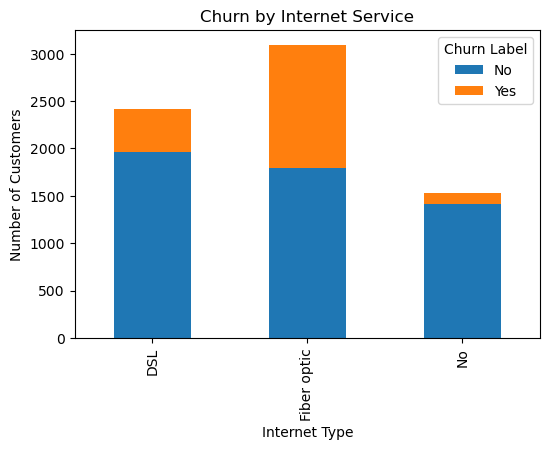

In [20]:
internet_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Type")
plt.ylabel("Number of Customers")

plt.show()

In [21]:
#Churn by Customer Segment
segment_churn = pd.crosstab(df["Customer Segment"],df["Churn Label"])
print(segment_churn)

Churn Label         No   Yes
Customer Segment            
Loyal Customer    2643   358
New Customer      1149  1037
Regular Customer  1382   474


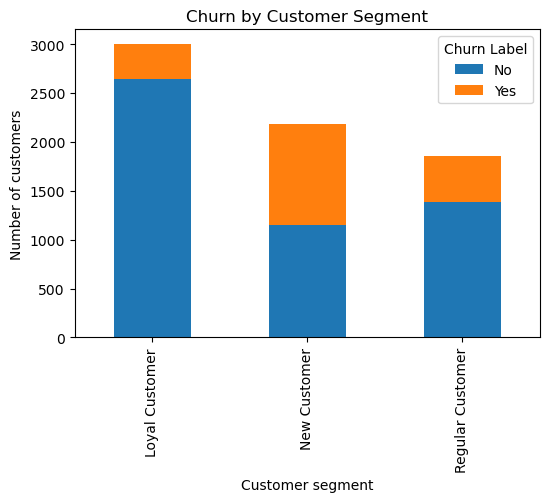

In [22]:
segment_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)
plt.title("Churn by Customer Segment")
plt.xlabel("Customer segment")
plt.ylabel("Number of customers")
plt.show()

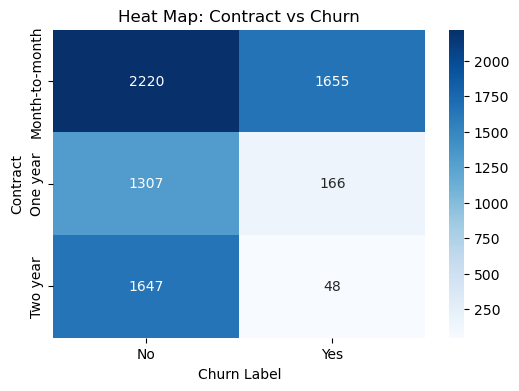

In [23]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(contract_churn, annot=True, fmt="d", cmap="Blues")

plt.title("Heat Map: Contract vs Churn")

plt.show()

Geographic Analysis

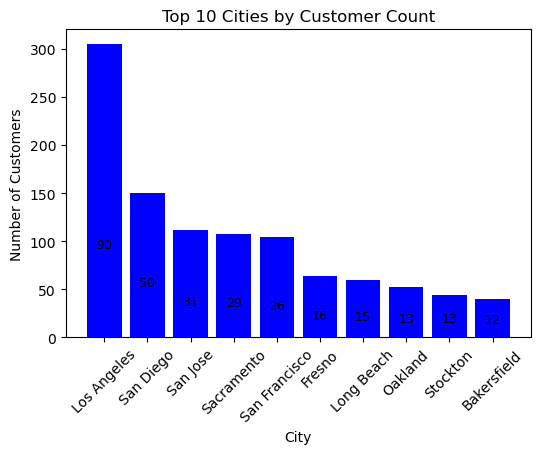

In [29]:
#Top 10 Cities by Number of Customers
city = df["City"].value_counts().head(10)

plt.figure(figsize=(6,4))

bar = plt.bar(city.index, city.values, color="blue")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             int(bar.get_height()),
             ha="center",
             va="bottom",
             fontsize=9)

plt.title("Top 10 Cities by Customer Count")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.show()

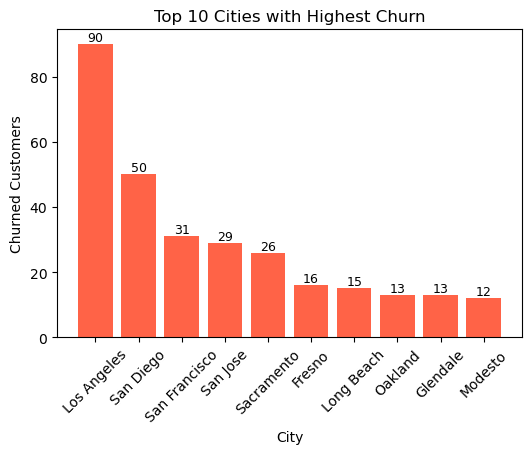

In [27]:
#Top 10 Cities by Churn
churn_city = (df[df["Churn Label"]=="Yes"]["City"].value_counts().head(10))
plt.figure(figsize=(6,4))

bars = plt.bar(churn_city.index,
               churn_city.values,
               color="tomato")

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             int(bar.get_height()),
             ha="center",
             va="bottom",
             fontsize=9)

plt.title("Top 10 Cities with Highest Churn")
plt.xlabel("City")
plt.ylabel("Churned Customers")
plt.xticks(rotation=45)

plt.show()

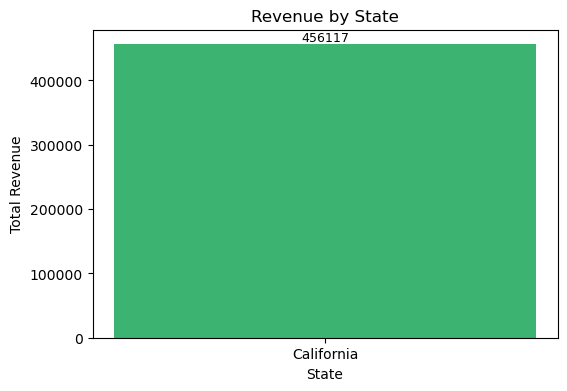

In [30]:
#Revenue by State
state_revenue = (df.groupby("State")["Monthly Charges"].sum().sort_values(ascending=False))
plt.figure(figsize=(6,4))

bars = plt.bar(state_revenue.index,
               state_revenue.values,
               color="mediumseagreen")

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             round(bar.get_height()),
             ha="center",
             va="bottom",
             fontsize=9)

plt.title("Revenue by State")
plt.xlabel("State")
plt.ylabel("Total Revenue")

plt.show()

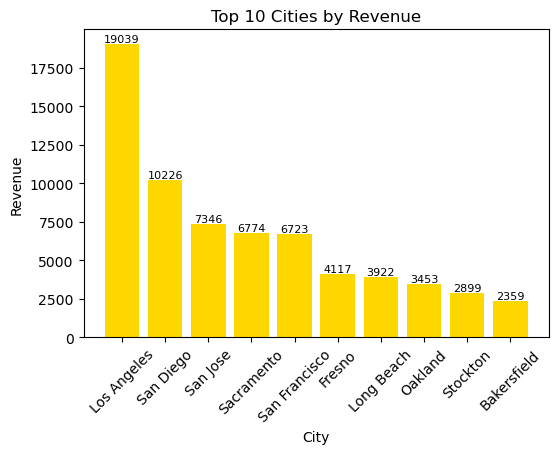

In [ ]:
#Revenue by City (Top 10)
city_revenue = (
    df.groupby("City")["Monthly Charges"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(6,4))

bars = plt.bar(city_revenue.index,
               city_revenue.values,
               color="gold")

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             round(bar.get_height()),
             ha="center",
             va="bottom",
             fontsize=8)

plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [32]:
print(df.columns.tolist())

['Unnamed: 0', 'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason', 'Service Adoption Score', 'Customer Segment', 'Revenue Segment', 'Risk Category']


In [33]:
!pip install squarify

  Obtaining dependency information for squarify from https://files.pythonhosted.org/packages/b7/3c/eedbe9fb07cc20fd9a8423da14b03bc270d0570b3ba9174a4497156a2152/squarify-0.4.4-py3-none-any.whl.metadata


In [34]:
import squarify

In [37]:
#Top Churn Reasons
churn_reason = (
    df[df["Churn Label"] == "Yes"]["Churn Reason"]
    .value_counts()
)


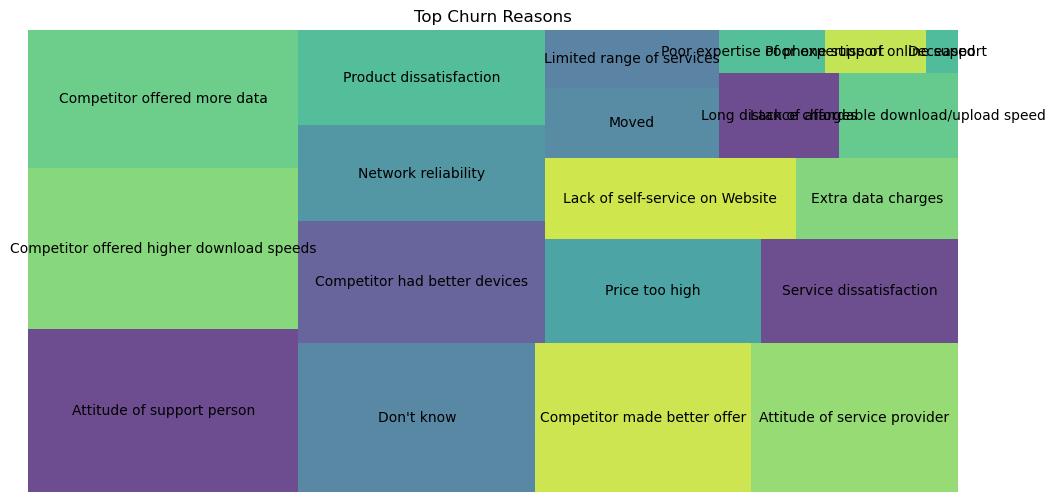

In [38]:
plt.figure(figsize=(12,6))

squarify.plot(
    sizes=churn_reason.values,
    label=churn_reason.index,
    alpha=0.8
)

plt.title("Top Churn Reasons")
plt.axis("off")

plt.show()

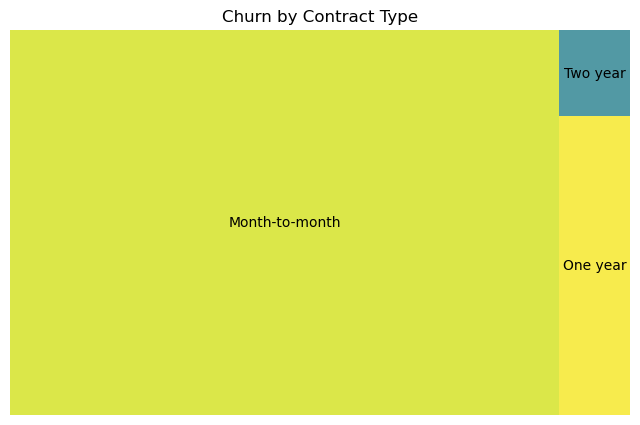

In [40]:
#Churn Reason by Contract
contract_reason = (
    df[df["Churn Label"]=="Yes"]
    .groupby("Contract")["Churn Reason"]
    .count()
)
plt.figure(figsize=(8,5))

squarify.plot(
    sizes=contract_reason.values,
    label=contract_reason.index,
    alpha=0.8
)

plt.title("Churn by Contract Type")
plt.axis("off")

plt.show()

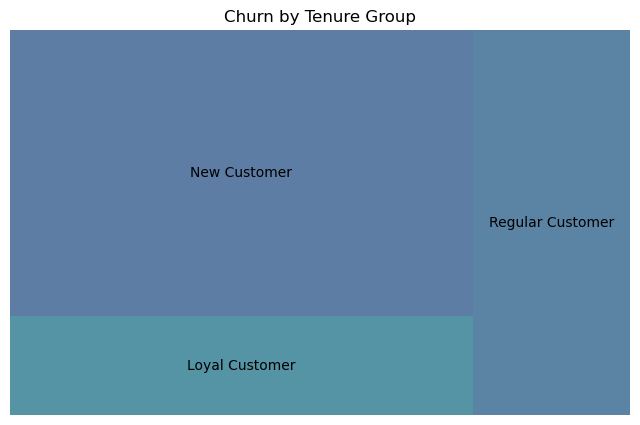

In [43]:
#Churn Reason by Tenure Group
tenure_reason = (
    df[df["Churn Label"]=="Yes"]
    .groupby("Customer Segment")["Churn Reason"]
    .count()
)
plt.figure(figsize=(8,5))

squarify.plot(
    sizes=tenure_reason.values,
    label=tenure_reason.index,
    alpha=0.8
)

plt.title("Churn by Tenure Group")
plt.axis("off")

plt.show()